# Galaxy - AGN Classification

Both galaxies and active galactic nuclei (AGN) are extragalactic sources. They both undergo ionizing processes, we'd like to distinguish the ionization processes happening in a galaxy vs AGN. This teaches us about whether the galaxy is star-forming, quiescent (no longer makes stars), etc. 

Builds a single table with:
- **MPA-JHU**: BPT emission line fluxes + classifications (Hα, Hβ, [NII], [OIII], [SII], [OI])

Later, we'll add other wavelengths!

#### Goal: Build a classifier that constructs a succesful BPT diagram.

## 0. Install dependencies

In [ ]:
import os
import sys

# Safely install requirements to the current notebook environment
os.system(f"{sys.executable} -m pip install -r requirements.txt")


All packages installed. Restart kernel now if this is your first run.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## 1. Imports & configuration

In [2]:
import os
import requests
from pathlib import Path
from io import BytesIO

import numpy as np
import pandas as pd
from tqdm import tqdm

import astropy.io.fits as fits
from astropy.table import Table, join, vstack
from astropy.coordinates import SkyCoord, match_coordinates_sky
import astropy.units as u

from astroquery.sdss import SDSS
from astroquery.vizier import Vizier
import pyvo

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
%matplotlib inline

# ── Configuration ────────────────────────────────────────────────────────────
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

# Crossmatch radius in arcseconds
MATCH_RADIUS_ARCSEC = 2.0   # tight for optical-optical
RADIO_MATCH_ARCSEC  = 5.0   # looser for FIRST (5" beam)
XRAY_MATCH_ARCSEC   = 10.0  # looser for X-ray

# # For testing: set to True to use a small subsample first
# # Set to False to download and process the full catalogs
# TEST_MODE = True
# TEST_N    = 5_000   # number of MPA-JHU rows to keep in test mode

# print(f'Data directory: {DATA_DIR.resolve()}')
# print(f'Test mode: {TEST_MODE} (N={TEST_N if TEST_MODE else "ALL"})')

## 2. MPA-JHU catalog — BPT lines + classifications

Download the official MPA-JHU FITS files directly from MPA Garching.
These are the authoritative releases used in all published BPT work.
We then optionally supplement with an SDSS SQL query for RA/Dec/redshift.

Files:
- `galSpecInfo`  — specobjid, RA, Dec, z, S/N
- `galSpecLine`  — all emission line fluxes + EWs + errors  
- `galSpecExtra` — D4000, HdeltaA, etc.
- `galSpecIndx`  — spectral indices

Column name notes (these differ from what SDSS SkyServer exposes):
- BPT class: `BPTCLASS` (int): 1=SF, 2=Low S/N SF, 3=Composite, 4=AGN, 5=Low S/N LINER
- Emission lines in galSpecLine use names like `H_ALPHA_FLUX`, `NII_6548_FLUX`, etc.
- Stellar mass / SFR live in separate `totsfr_dr7_v5_2.fits` and `totlgm_dr7_v5_2.fits` files


### Download the data

In [3]:
import gzip, shutil

# ── MPA-JHU direct FITS downloads ─────────────────────────────────────────
# Primary mirror: MPA Garching
MPA_BASE = 'https://wwwmpa.mpa-garching.mpg.de/SDSS/DR7/Data/'

MPA_FILES = {
    'info':  'gal_info_dr7_v5_2.fit.gz',
    'line':  'gal_line_dr7_v5_2.fit.gz',
    'extra': 'gal_indx_dr7_v5_2.fit.gz',
    
}

def download_fits_gz(filename, dest_dir, base_url, fallback_url=None):
    """Download a .fits.gz file, decompress it, return path to .fits."""
    fits_path = dest_dir / filename.replace('.gz', '')
    if fits_path.exists():
        print(f'  Already exists: {fits_path.name}')
        return fits_path
    gz_path = dest_dir / filename
    for url_base in ([base_url] + ([fallback_url] if fallback_url else [])):
        url = url_base + filename
        print(f'  Trying: {url}')
        try:
            r = requests.get(url, stream=True, timeout=120)
            r.raise_for_status()
            total = int(r.headers.get('content-length', 0))
            with open(gz_path, 'wb') as f, tqdm(
                desc=f'  {filename}', total=total, unit='B',
                unit_scale=True, leave=False
            ) as bar:
                for chunk in r.iter_content(65536):
                    f.write(chunk)
                    bar.update(len(chunk))
            # Decompress
            print(f'  Decompressing {filename}...')
            with gzip.open(gz_path, 'rb') as fin, open(fits_path, 'wb') as fout:
                shutil.copyfileobj(fin, fout)
            gz_path.unlink()
            print(f'{fits_path.name}')
            return fits_path
        except Exception as e:
            print(f'  Failed ({e}), trying next URL...')
    raise RuntimeError(f'Could not download {filename} from any mirror.')

print('Downloading MPA-JHU FITS files...')
local_files = {}
for key, fname in MPA_FILES.items():
    local_files[key] = download_fits_gz(fname, DATA_DIR, MPA_BASE)

print('\nAll MPA-JHU files ready.')

  Already exists: gal_info_dr7_v5_2.fit
  Already exists: gal_line_dr7_v5_2.fit
  Already exists: gal_indx_dr7_v5_2.fit

All MPA-JHU files ready.


### Load in the dataframes

In [4]:
# ── Load and inspect each table ────────────────────────────────────────────
print('Loading galSpecInfo...')
info  = Table.read(local_files['info'],  hdu=1)
print(f'  {len(info):,} rows, columns: {info.colnames}')

print('Loading galSpecLine...')
line  = Table.read(local_files['line'],  hdu=1)
print(f'  {len(line):,} rows, columns (first 15): {line.colnames[:15]}')

print('Loading galSpecExtra...')
extra = Table.read(local_files['extra'], hdu=1)
print(f'  {len(extra):,} rows, columns: {extra.colnames}')

for tbl in [info, line, extra]:
    for col in tbl.colnames:
        if tbl[col].dtype.kind == 'S':   
            tbl[col] = np.char.strip(tbl[col].astype(str))

Loading galSpecInfo...
  927,552 rows, columns: ['PLATEID', 'MJD', 'FIBERID', 'PHOTOID', 'RA', 'DEC', 'PLUG_MAG', 'PRIMTARGET', 'SECTARGET', 'TARGETTYPE', 'SPECTROTYPE', 'SUBCLASS', 'Z', 'Z_ERR', 'Z_WARNING', 'V_DISP', 'V_DISP_ERR', 'SN_MEDIAN', 'E_BV_SFD', 'ZTWEAK', 'ZTWEAK_ERR', 'SPECTRO_MAG', 'KCOR_MAG', 'KCOR_MODEL_MAG', 'RELEASE']
Loading galSpecLine...
  927,552 rows, columns (first 15): ['PLATEID', 'FIBERID', 'SIGMA_BALMER', 'SIGMA_BALMER_ERR', 'SIGMA_FORBIDDEN', 'SIGMA_FORBIDDEN_ERR', 'V_OFF_BALMER', 'V_OFF_BALMER_ERR', 'V_OFF_FORBIDDEN', 'V_OFF_FORBIDDEN_ERR', 'OII_3726_CONT', 'OII_3726_CONT_ERR', 'OII_3726_REQW', 'OII_3726_REQW_ERR', 'OII_3726_EQW']
Loading galSpecExtra...
  927,552 rows, columns: ['PLATEID', 'FIBERID', 'LICK_CN1', 'LICK_CN1_ERR', 'LICK_CN1_MODEL', 'LICK_CN1_SUB', 'LICK_CN1_SUB_ERR', 'LICK_CN2', 'LICK_CN2_ERR', 'LICK_CN2_MODEL', 'LICK_CN2_SUB', 'LICK_CN2_SUB_ERR', 'LICK_CA4227', 'LICK_CA4227_ERR', 'LICK_CA4227_MODEL', 'LICK_CA4227_SUB', 'LICK_CA4227_SUB_ERR',

In [ ]:
# ── Merge the three tables on row index (they are row-matched by construction) ──
# All three galSpec files have identical row ordering keyed by SPECOBJID.
# Verify this, then merge.

assert len(info) == len(line) == len(extra), 'Row counts differ — something is wrong'

# Identify the BPT emission line columns we need.
# galSpecLine stores fluxes as 1D arrays (one value per object per line).
# Column names are uppercase: H_ALPHA_FLUX, H_ALPHA_FLUX_ERR, NII_6583_FLUX, etc.
# Print all line columns so you can verify:
line_cols_all = line.colnames
bpt_line_cols = [c for c in line_cols_all if any(x in c.upper() for x in [
    'H_ALPHA', 'H_BETA', 'NII_6583', 'OIII_5007', 'SII_6717', 'SII_6731', 'OI_6300', 'NII_6548'
])]
print('BPT-relevant line columns found:')
for c in bpt_line_cols:
    print(f'  {c}')

# Build master DataFrame
names = [name for name in info.colnames if len(info[name].shape) <= 1]

df_info  = info[names].to_pandas()
df_line  = line[bpt_line_cols].to_pandas()
df_extra = extra[['D4000', 'D4000_ERR', 'LICK_HD_A', 'LICK_HD_A_ERR']].to_pandas()

# Standardise to lowercase
df_info.columns  = [c.lower() for c in df_info.columns]
df_line.columns  = [c.lower() for c in df_line.columns]
df_extra.columns = [c.lower() for c in df_extra.columns]

df = pd.concat([df_info, df_line, df_extra], axis=1)

# Apply redshift filter
z_col = next(c for c in df.columns if c in ['z', 'redshift'])
df = df[(df[z_col] >= 0.01) & (df[z_col] <= 0.30)].copy()
df = df.rename(columns={z_col: 'redshift'})
df


BPT-relevant line columns found:
  H_BETA_CONT
  H_BETA_CONT_ERR
  H_BETA_REQW
  H_BETA_REQW_ERR
  H_BETA_EQW
  H_BETA_EQW_ERR
  H_BETA_SEQW
  H_BETA_SEQW_ERR
  H_BETA_FLUX
  H_BETA_FLUX_ERR
  H_BETA_INST_RES
  H_BETA_CHISQ
  OIII_5007_CONT
  OIII_5007_CONT_ERR
  OIII_5007_REQW
  OIII_5007_REQW_ERR
  OIII_5007_EQW
  OIII_5007_EQW_ERR
  OIII_5007_SEQW
  OIII_5007_SEQW_ERR
  OIII_5007_FLUX
  OIII_5007_FLUX_ERR
  OIII_5007_INST_RES
  OIII_5007_CHISQ
  OI_6300_CONT
  OI_6300_CONT_ERR
  OI_6300_REQW
  OI_6300_REQW_ERR
  OI_6300_EQW
  OI_6300_EQW_ERR
  OI_6300_SEQW
  OI_6300_SEQW_ERR
  OI_6300_FLUX
  OI_6300_FLUX_ERR
  OI_6300_INST_RES
  OI_6300_CHISQ
  NII_6548_CONT
  NII_6548_CONT_ERR
  NII_6548_REQW
  NII_6548_REQW_ERR
  NII_6548_EQW
  NII_6548_EQW_ERR
  NII_6548_SEQW
  NII_6548_SEQW_ERR
  NII_6548_FLUX
  NII_6548_FLUX_ERR
  NII_6548_INST_RES
  NII_6548_CHISQ
  H_ALPHA_CONT
  H_ALPHA_CONT_ERR
  H_ALPHA_REQW
  H_ALPHA_REQW_ERR
  H_ALPHA_EQW
  H_ALPHA_EQW_ERR
  H_ALPHA_SEQW
  H_ALPHA_SEQW_E

,plateid,mjd,fiberid,ra,dec,primtarget,sectarget,targettype,spectrotype,subclass,...,sii_6731_inst_res,sii_6731_chisq,h_beta_abs,h_beta_abs_model,h_alpha_abs,h_alpha_abs_model,d4000,d4000_err,lick_hd_a,lick_hd_a_err
0,266,51602,1,146.714203,-1.041304,96,0,GALAXY,GALAXY,NaN,...,63.754230,0.461399,2.229842,2.153928,1.777556,1.845598,1.897241,0.015577,0.282290,0.508994
1,266,51602,2,146.919449,-0.990492,64,0,GALAXY,GALAXY,NaN,...,59.727711,0.873948,0.628890,2.672791,1.804353,1.602346,1.813719,0.050477,-1.770524,2.158751
2,266,51602,4,146.859833,-0.808902,96,0,GALAXY,GALAXY,NaN,...,61.625584,1.358843,1.606125,2.151871,0.604910,1.744240,2.299695,0.095407,-1.599058,2.479654
4,266,51602,6,146.963898,-0.545003,64,0,GALAXY,GALAXY,STARBURST,...,63.046791,1.431984,2.477440,3.623374,1.714617,2.556636,1.499876,0.068530,5.306412,2.770213
5,266,51602,8,146.607208,-1.240753,64,0,GALAXY,GALAXY,NaN,...,62.363316,0.966615,1.750695,2.026363,1.668603,1.819472,2.027538,0.041432,0.527210,1.302923
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
927547,2974,54592,633,260.743164,31.944035,64,0,GALAXY,GALAXY,NaN,...,60.681091,0.344452,2.261509,2.115254,1.953359,1.814896,1.983766,0.013186,-1.091449,0.469720
927548,2974,54592,635,260.800568,31.898993,64,0,GALAXY,GALAXY,STARFORMING BROADLINE,...,50.843090,0.811513,1.712089,2.105363,1.427004,1.679928,1.909592,0.019207,0.699850,0.709464
927549,2974,54592,636,260.716003,32.024277,96,0,GALAXY,GALAXY,NaN,...,50.214436,1.123171,1.784459,2.035304,1.415590,1.710906,2.077784,0.027006,0.944143,0.876546
927550,2974,54592,637,260.697235,32.285629,64,0,GALAXY,GALAXY,NaN,...,53.772568,1.171011,1.786945,2.143330,1.485120,1.499287,2.150003,0.020461,-2.350705,0.679861


In [15]:
pd.unique(df['subclass'])

<StringArray>
[                    nan,             'STARBURST',           'STARFORMING',
             'BROADLINE',                   'AGN', 'STARFORMING BROADLINE',
         'AGN BROADLINE',   'STARBURST BROADLINE']
Length: 8, dtype: str

In [6]:
### what are the available labels
np.unique(df['spectrotype']), np.unique(df['subclass'][~df['subclass'].isna()])

(array(['GALAXY', 'QSO'], dtype=object),
 array(['AGN', 'AGN BROADLINE', 'BROADLINE', 'STARBURST',
        'STARBURST BROADLINE', 'STARFORMING', 'STARFORMING BROADLINE'],
       dtype=object))

In [ ]:
COL = ['h_alpha_flux', 'h_alpha_flux_err','h_beta_flux','h_beta_flux_err',
           'nii_6548_flux', 'nii_6548_flux_err', 'oiii_5007_flux',
           'oiii_5007_flux_err','sii_6717_flux','sii_6731_flux','oi_6300_flux',
             'ra', 'dec', 'd4000', 'lick_hd_a' ]

### Clean the data:

In [ ]:
# ── Compute BPT log line ratios ────────────────────────────────────────────
ha  = df['h_alpha_flux']
hb  = df['h_beta_flux']
nii = df['nii_6548_flux']
oiii= df['oiii_5007_flux']

good = (ha > 0) & (hb > 0) & (nii > 0) & (oiii > 0)

df['log_NII_Ha']  = np.where(good, np.log10(nii / ha),   np.nan)
df['log_OIII_Hb'] = np.where(good, np.log10(oiii / hb),  np.nan)
df['balmer_dec']  = np.where(ha > 0, ha / hb.replace(0, np.nan), np.nan)

### Assign labels:

In [ ]:
# Signal-to-noise cuts
good = (
    (df['h_alpha_flux'] / df['h_alpha_flux_err'] > 3) &
    (df['h_beta_flux'] / df['h_beta_flux_err'] > 3) &
    (df['oiii_5007_flux'] / df['oiii_5007_flux_err'] > 3) &
    (df['nii_6548_flux'] / df['nii_6548_flux_err'] > 3)
)

df = df[good].copy()

x = np.log10(df['nii_6548_flux'] / df['h_alpha_flux'])
y = np.log10(df['oiii_5007_flux'] / df['h_beta_flux'])

kauff = 0.61/(x - 0.05) + 1.3
kewley = 0.61/(x - 0.47) + 1.19

df['bptclass'] = 'AGN'
df.loc[y < kewley, 'bptclass'] = 'Composite'
df.loc[y < kauff, 'bptclass'] = 'Star-forming'

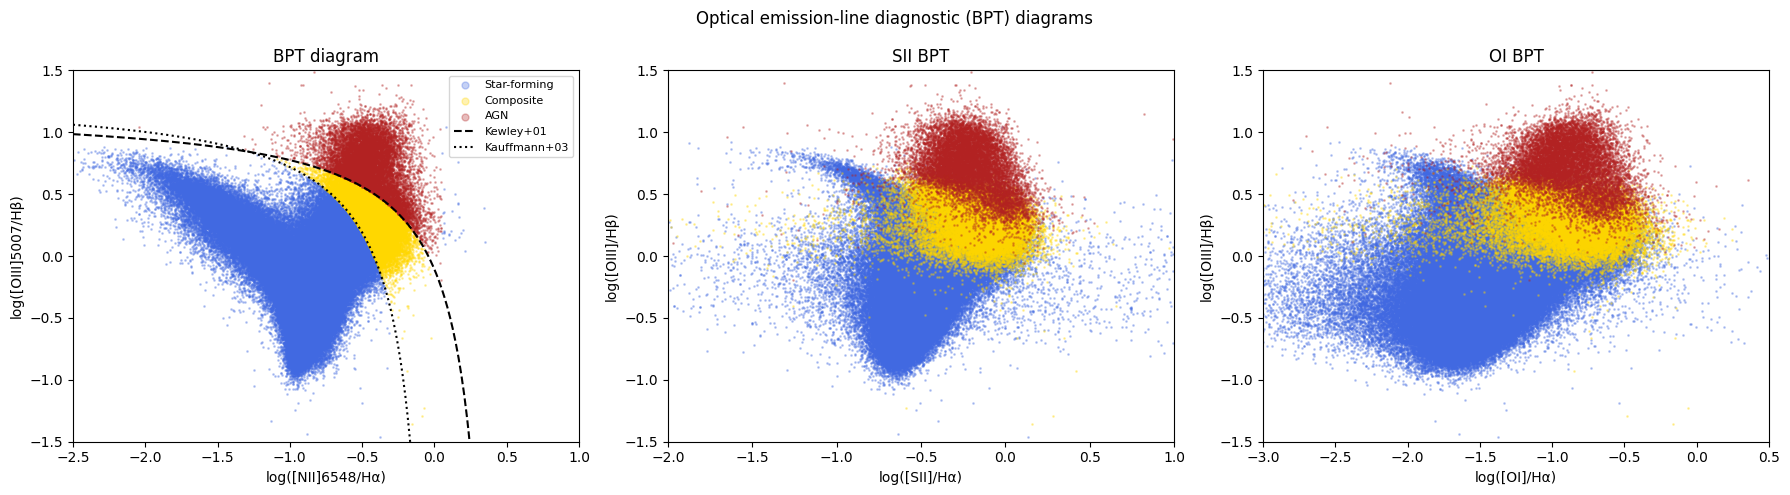

In [11]:
# ── BPT diagnostic plots ───────────────────────────────────────────────────
colors = {'Star-forming': 'royalblue', 
          'Composite': 'gold', 'AGN': 'firebrick'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for label, color in colors.items():
    sub = df[df['bptclass'] == label]
    axes[0].scatter(sub['log_NII_Ha'],  sub['log_OIII_Hb'], s=1, alpha=0.3, color=color, label=label)
    if 'log_SII_Ha' in df.columns:
        axes[1].scatter(sub['log_SII_Ha'],  sub['log_OIII_Hb'], s=1, alpha=0.3, color=color)
    if 'log_OI_Ha' in df.columns:
        axes[2].scatter(sub['log_OI_Ha'],   sub['log_OIII_Hb'], s=1, alpha=0.3, color=color)

x_kew = np.linspace(-2.5, 0.4, 300)
axes[0].plot(x_kew, 0.61/(x_kew - 0.47) + 1.19, 'k--', lw=1.5, label='Kewley+01')
x_kau = np.linspace(-2.5, 0.0, 300)
axes[0].plot(x_kau, 0.61/(x_kau - 0.05) + 1.3,  'k:',  lw=1.5, label='Kauffmann+03')

axes[0].set(xlabel='log([NII]6548/Hα)', ylabel='log([OIII]5007/Hβ)',
            title='BPT diagram', xlim=(-2.5, 1), ylim=(-1.5, 1.5))
axes[0].legend(markerscale=5, fontsize=8)
axes[1].set(xlabel='log([SII]/Hα)', ylabel='log([OIII]/Hβ)',
            title='SII BPT', xlim=(-2, 1), ylim=(-1.5, 1.5))
axes[2].set(xlabel='log([OI]/Hα)',  ylabel='log([OIII]/Hβ)',
            title='OI BPT',  xlim=(-3, 0.5), ylim=(-1.5, 1.5))
fig.suptitle('Optical emission-line diagnostic (BPT) diagrams')
plt.tight_layout()
plt.savefig(DATA_DIR / 'bpt_diagnostic.png', dpi=150, bbox_inches='tight')
plt.show()

### Now classify these objects yourself! 
You can also cross match with the following datasets/wavelengths and improve your classifer. 
- **GSWLC-2**: GALEX NUV/FUV + SDSS ugriz + WISE W1-W4 + SFR + M★
- **FIRST**: 1.4 GHz radio flux densities
- **SDSS ROSAT/XMM VAC**: X-ray detections
- **COSMOS2020**: deep-field panchromatic catalog (30+ bands, UV→IR)